In [1]:
import torch
import torch.nn as nn
import torchvision
from torchvision.datasets import CIFAR10
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

### Data Loading and Preprocessing

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

In [3]:
trainset = CIFAR10(root='./data', train = True, download = True, transform=transform)
testset = CIFAR10(root='./data', train = False, download = True, transform=transform)

In [4]:
trainloader= DataLoader(trainset, batch_size=64, shuffle=True)
testloader= DataLoader(testset, batch_size=64)


### Building the Model

In [5]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN,self).__init__()
        self.conv_layers = nn.Sequential(
            #1st layer
            nn.Conv2d(3,32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2,2),
            #2nd layer
            nn.Conv2d(32,64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2,2),
            #3rd layer
            nn.Conv2d(64,128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2,2),
        )
        self.fc_layers= nn.Sequential(
            nn.Linear(4*4*128, 256),
            nn.ReLU(),

            nn.Linear(256, 10)
        )

    def forward(self,x):
        x= self.conv_layers(x)
        x= torch.flatten(x, start_dim=1)
        x= self.fc_layers(x)
        return x
        

In [6]:
model = CNN()

In [7]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())


### Training the CNN

In [8]:
epochs = 10
train_losses=[]
val_losses=[]
for epoch in range(epochs):
    model.train()
    train_loss=0.0
    for xb, yb in trainloader:
        optimizer.zero_grad()
        outputs = model.forward(xb)
        loss = criterion(outputs, yb)
        loss.backward()
        optimizer.step()
        train_loss+=loss.item()
    epoch_train_loss= train_loss/len(trainloader)
    train_losses.append(epoch_train_loss)
    val_loss=0.0
    model.eval()
    with torch.no_grad():
        for xb, yb in testloader:
            outputs = model.forward(xb)
            loss = criterion(outputs, yb)
            val_loss+=loss.item()
        epoch_val_loss= val_loss/len(testloader)
    val_losses.append(epoch_val_loss)
    print(f"epoch {epoch+1}/{epochs}: training_loss = {epoch_train_loss} & val_loss = {epoch_val_loss}")            
            

epoch 1/10: training_loss = 1.4040492226553085 & val_loss = 1.1076929880555269
epoch 2/10: training_loss = 0.9610989406285688 & val_loss = 0.9102235246615805
epoch 3/10: training_loss = 0.7622993511083486 & val_loss = 0.7948118829803102
epoch 4/10: training_loss = 0.6373728619664526 & val_loss = 0.7370643255057608
epoch 5/10: training_loss = 0.527056048898136 & val_loss = 0.7506181962171178
epoch 6/10: training_loss = 0.4318312724380542 & val_loss = 0.7255622767339087
epoch 7/10: training_loss = 0.34619452699523445 & val_loss = 0.8435371846530089
epoch 8/10: training_loss = 0.2716053667885568 & val_loss = 0.8798282343870515
epoch 9/10: training_loss = 0.20817916059528319 & val_loss = 0.9535365319176085
epoch 10/10: training_loss = 0.1651414344349252 & val_loss = 1.0231074480114468


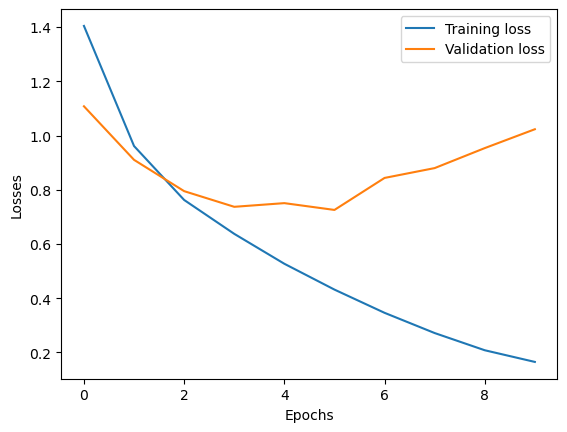

In [10]:
import matplotlib.pyplot as plt
import pandas as pd
loss_df = pd.DataFrame({
    "Training Loss" : train_losses,
    "Val Loss": val_losses
})
plt.plot(loss_df["Training Loss"], label="Training loss")
plt.plot(loss_df["Val Loss"], label="Validation loss")
plt.xlabel("Epochs")
plt.ylabel("Losses")
plt.legend()

### Model evaluation

In [11]:
correct_labels = 0
total_labels = 0

model.eval()

with torch.no_grad():
    for images, labels in testloader:
        outputs = model.forward(images)
        _, predicted = torch.max(outputs,1)
        correct_labels+=(predicted==labels).sum().item()
        total_labels+=labels.size(0)

print(f"Accuracy = {correct_labels/total_labels *100}")
        

Accuracy = 75.06
